# Feature Evaluation — CME Futures

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against the 5-day forward return label. Produces triage decisions for Ch11 modeling.

**Learning Objectives**:
- Assess predictive content via HAC-adjusted Information Coefficients
- Apply Benjamini-Hochberg FDR correction for multiple testing
- Diagnose feature shape (quantile monotonicity) and redundancy (pairwise correlation)
- Triage features as PROCEED / REVISE / STOP for downstream modeling

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation);
Chapter 9, Section 9.5 (Temporal Feature Integration)

**Prerequisites**: Run `03_financial_features.py` and `04_model_based_features.py` first.

In [1]:
"""Feature Evaluation - CME Futures

Consolidated evaluation of Ch8 financial features and Ch9 temporal features
against forward return labels. Produces triage decisions for Ch11 modeling.
"""

import warnings
from datetime import date

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from plotly.subplots import make_subplots

import utils.style as style
from utils.paths import get_case_study_dir

# Register the ML4T Plotly template (colorway, fonts, gridlines) as the default
# and expose the book palette so every figure sources color from utils.style.
style.apply_ml4t_style()
COLORS = style.COLORS
GRAY_FILLS = style.GRAY_FILLS

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "cme_futures"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

## Load Artifacts and Build Evaluation Panel

We combine three upstream artifacts:
- **Financial features** (`features/financial.parquet`): ~60 features from Ch8
- **Temporal features** (`features/model_based.parquet`): 9 features from Ch9
- **Primary label** (`labels/fwd_ret_5d.parquet`): 5-day forward return

CME futures data includes three contract positions per product (front month,
first deferred, second deferred). For cross-sectional IC evaluation we
**filter to front-month (position 0) only** — the three positions for the
same product share carry features and highly correlated price dynamics,
so including all three inflates the effective cross-section from 30
independent products to ~90 dependent entities, making t-statistics too
liberal. This matches the approach in `03_financial_features.py`'s inline evaluation.

**Holdout sealing.** Every statistic in this notebook — IC ranking, HAC
significance, BH-FDR discovery, and the PROCEED/STOP triage — is a feature-
selection input for Ch11. We therefore seal the evaluation to
`[START, holdout_start)` (`holdout_start` from `setup.yaml`, here 2024-01-01);
the 2024–2025 holdout is never touched here so it stays unbiased for the final
model assessment downstream.

In [4]:
# Load features — filter to front month for evaluation
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet").filter(
    pl.col("position") == 0
)
temporal = pl.read_parquet(CASE_DIR / "features" / "model_based.parquet").filter(
    pl.col("position") == 0
)
# model_based.parquet now carries one row per (timestamp, product, position, fold);
# drop fold and de-dup so the join doesn't multiply the eval panel by fold count.
if "fold" in temporal.columns:
    temporal = temporal.drop("fold").unique(subset=["timestamp", "product"], keep="last")

# Load primary label (front month only)
label_df = pl.read_parquet(CASE_DIR / "labels" / "fwd_ret_5d.parquet").filter(
    pl.col("position") == 0
)
label_col = [c for c in label_df.columns if c not in ("timestamp", "product", "position")][0]

# Load evaluation config from setup.yaml (single source of truth)
import yaml

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup_config = yaml.safe_load(f)
eval_config = setup_config["evaluation"]

# Holdout boundary — feature evaluation and triage must be sealed against the
# holdout (setup.yaml `holdout_start`). Any IC ranking, FDR discovery, or
# PROCEED/STOP decision computed with holdout data leaks the sealed window into
# feature selection, so we evaluate strictly on [START, holdout_start).
HOLDOUT_START = date(*map(int, eval_config["holdout_start"].split("-")))

# Join keys — position is fixed at 0 but kept for join consistency
JOIN_COLS = ["timestamp", "product", "position"]
DATE_COL = "timestamp"

In [5]:
# Identify feature columns (exclude metadata and composite signals)
METADATA_COLS = {"timestamp", "product", "position", "ls_signal", "risk_adj_score"}
financial_cols = [c for c in features.columns if c not in METADATA_COLS]
temporal_cols = [c for c in temporal.columns if c not in JOIN_COLS]

# Build unified eval panel (front-month only, ~30 products per date)
eval_panel = features.drop(["ls_signal", "risk_adj_score"], strict=False).join(
    temporal, on=JOIN_COLS, how="left"
)
eval_panel = eval_panel.join(label_df, on=JOIN_COLS, how="inner")

# Seal the holdout: every IC / FDR / triage statistic below is a selection input
# for Ch11 modeling, so it may only see pre-holdout data.
eval_panel = eval_panel.filter(pl.col(DATE_COL) < HOLDOUT_START)

all_feature_cols = financial_cols + temporal_cols

# Optional: reduce universe for fast dev
if MAX_SYMBOLS > 0:
    top = eval_panel.group_by("product").len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col("product").is_in(top["product"]))

n_rows = len(eval_panel)
n_symbols = eval_panel["product"].n_unique()
n_dates = eval_panel[DATE_COL].n_unique()
print(f"Eval panel: {n_rows:,} rows, {n_symbols} products, {n_dates} dates")
print(f"  (front-month only — position == 0; sealed to < {HOLDOUT_START})")
print(
    f"Features: {len(financial_cols)} financial + {len(temporal_cols)} temporal"
    f" = {len(all_feature_cols)} total"
)
print(f"Label: {label_col}")

Eval panel: 97,486 rows, 30 products, 3336 dates
  (front-month only — position == 0; sealed to < 2024-01-01)
Features: 60 financial + 9 temporal = 69 total
Label: fwd_ret_5d


## 0. Data Quality Gate

Before any statistical evaluation, verify that upstream artifacts are free of
critical defects: negative prices, infinite values in features or labels, and
extreme return magnitudes. This gate catches data pipeline failures (e.g.,
broken back-adjustment, division by zero in derived features) before they
propagate to model training where they surface as cryptic `ValueError`s.

In [6]:
from utils.data_quality import validate_modeling_inputs

# Run quality gate on raw inputs (before any filtering or joining)
quality_result = validate_modeling_inputs(
    features_df=features,
    label_df=label_df,
    feature_cols=[c for c in features.columns if c not in {"timestamp", "product", "position"}],
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col="product",
    max_abs_return=1.0,  # 5-day futures returns (max observed ~0.90, CL/NG)
    max_abs_feature=1e6,
    fail_on_critical=True,
)

# Also check temporal features if loaded
if len(temporal) > 0:
    temporal_feature_cols = [c for c in temporal.columns if c not in JOIN_COLS]
    temporal_quality = validate_modeling_inputs(
        features_df=temporal,
        label_df=label_df,
        feature_cols=temporal_feature_cols,
        label_col=label_col,
        join_cols=JOIN_COLS,
        asset_col="product",
        max_abs_return=0.5,
        max_abs_feature=1e6,
        fail_on_critical=True,
    )

Data Quality Gate: ALL CLEAR
Data Quality Gate: 0 CRITICAL, 2 WARNING
  [!] WARNING: fwd_ret_5d has 4 values with |ret| > 50% (0.00% of 113,356 rows)
  [!] WARNING: 5 features have values |x| > 1e+06: fft_spectral_energy(7560), fft_dominant_period(7560), fft_spectral_entropy(7560), fft_energy_63d(7560), fft_energy_126d(7560)


## 1. Correctness Screens

Before evaluating predictive power, we check each feature for:
- **Coverage**: Fraction of non-null values (gate: $\geq 70\%$)
- **Staleness**: Fraction of dates where the value is unchanged from the prior date
  within the same product (gate: $\leq 50\%$)

Features failing either gate are triaged as STOP.

In [7]:
# Coverage: fraction non-null per feature
coverage = {}
for feat in all_feature_cols:
    n_valid = eval_panel[feat].drop_nulls().len()
    coverage[feat] = n_valid / n_rows

# Staleness: fraction unchanged from prior date (per product)
staleness = {}
for feat in all_feature_cols:
    df_sorted = eval_panel.select(["product", "timestamp", feat]).sort(["product", "timestamp"])
    stale_count = df_sorted.with_columns(
        (pl.col(feat) == pl.col(feat).shift(1).over("product")).alias("unchanged")
    )["unchanged"].sum()
    staleness[feat] = float(stale_count) / max(n_rows - n_symbols, 1)

In [8]:
# Correctness gate
correctness = {}
for feat in all_feature_cols:
    cov_ok = coverage[feat] >= 0.70
    stale_ok = staleness[feat] <= 0.50
    correctness[feat] = cov_ok and stale_ok

n_pass = sum(correctness.values())
n_fail = len(correctness) - n_pass
print(f"Correctness gate: {n_pass} PASS, {n_fail} FAIL")

if n_fail > 0:
    fail_df = pl.DataFrame(
        {
            "feature": [f for f, ok in correctness.items() if not ok],
            "coverage": [coverage[f] for f, ok in correctness.items() if not ok],
            "staleness": [staleness[f] for f, ok in correctness.items() if not ok],
        }
    )
    print(fail_df)

Correctness gate: 52 PASS, 17 FAIL
shape: (17, 3)
┌───────────────────────┬──────────┬───────────┐
│ feature               ┆ coverage ┆ staleness │
│ ---                   ┆ ---      ┆ ---       │
│ str                   ┆ f64      ┆ f64       │
╞═══════════════════════╪══════════╪═══════════╡
│ carry_rank_sector     ┆ 0.981187 ┆ 0.64544   │
│ carry_regime_num      ┆ 0.981187 ┆ 0.81997   │
│ curvature_21d         ┆ 0.598158 ┆ 0.000164  │
│ is_seasonal_sector    ┆ 1.0      ┆ 1.0       │
│ month_cos             ┆ 1.0      ┆ 0.953394  │
│ …                     ┆ …        ┆ …         │
│ arima_carry_forecast  ┆ 0.077242 ┆ 0.0       │
│ arima_carry_residual  ┆ 0.077242 ┆ 0.0       │
│ fft_dominant_period   ┆ 0.962107 ┆ 0.926274  │
│ hmm_carry_regime_prob ┆ 0.665757 ┆ 0.0       │
│ hmm_regime_duration   ┆ 0.665757 ┆ 0.003314  │
└───────────────────────┴──────────┴───────────┘


## 2. Univariate Association (IC + HAC)

For each feature that passes the correctness gate, compute the cross-sectional
Spearman IC time series: on each date, rank all ~30 front-month products
by the feature value and correlate against the forward return.

### Why HAC correction matters

The 5-day forward return label is computed daily, so consecutive observations
overlap by 4 days. This induces autocorrelation of order ~5 in the IC series,
inflating naive standard errors. HAC (Newey-West) standard errors with
bandwidth $= 5$ correct for this:

$$N_{\text{eff}} \approx \frac{N}{1 + 2\sum_{k=1}^{q} w_k \hat{\rho}_k}$$

where $w_k$ are Bartlett kernel weights and $\hat{\rho}_k$ are
autocorrelation estimates. With 5-day overlap, $N_{\text{eff}}$ is
roughly $N / 5$, so a sample of 3,500 daily ICs has effective size ~700.
Without HAC, we would overstate significance by a factor of $\sqrt{5} \approx 2.2$.

In [9]:
evaluable_features = [f for f in all_feature_cols if correctness[f]]
HAC_MAXLAGS = 5  # 5-day forward return → 5 trading days HAC bandwidth

ic_results = {}
ic_timeseries = {}
for feat in evaluable_features:
    valid = eval_panel.select([DATE_COL, "product", feat, label_col]).drop_nulls()
    if valid["product"].n_unique() < 2:
        continue

    # Compute cross-sectional Spearman IC per date using native Polars
    # (cross_sectional_ic_series joins on date_col only, which cross-joins multi-asset panels)
    ic_df = (
        valid.group_by(DATE_COL)
        .agg(
            pl.corr(feat, label_col, method="spearman").alias("ic"),
            pl.len().alias("n_obs"),
        )
        .filter(pl.col("n_obs") >= 10)
        .drop_nulls("ic")
        # Spearman corr of a feature that is constant across the cross-section on
        # a given date (e.g. calendar features shared by all products) is NaN;
        # Polars drop_nulls does NOT drop NaN, so filter it explicitly or these
        # zero-variance features pollute the IC ranking, BH-FDR, and figures.
        .filter(pl.col("ic").is_not_nan())
        .sort(DATE_COL)
    )
    if len(ic_df) >= 20:
        hac_stats = compute_ic_hac_stats(ic_df, ic_col="ic", maxlags=HAC_MAXLAGS)
        ic_results[feat] = hac_stats
        ic_timeseries[feat] = ic_df

print(f"Evaluated {len(ic_results)} features (of {len(evaluable_features)} evaluable)")

Evaluated 51 features (of 52 evaluable)


### Fold-Level Stability

Check whether IC sign is consistent across the 5 walk-forward folds.
Sign consistency $\geq 60\%$ (i.e., same sign in 3+ of 5 folds) indicates
a feature that works across market regimes, not just one favorable period.

In [10]:
# Derive fold boundaries from setup.yaml evaluation config
n_splits = eval_config["n_splits"]
holdout_start_year = int(eval_config["holdout_start"][:4])
train_years = int(eval_config["train_size"].rstrip("Y"))

splits = []
for i in range(n_splits):
    test_year = holdout_start_year - n_splits + i
    splits.append(
        {
            "test_start": date(test_year, 1, 1),
            "test_end": date(test_year, 12, 31),
        }
    )

# Per-fold IC
fold_stats = {}
for feat in ic_results:
    fold_ics = []
    for split in splits:
        ts = ic_timeseries[feat]
        fold_ic = ts.filter(
            (pl.col(DATE_COL) >= split["test_start"]) & (pl.col(DATE_COL) <= split["test_end"])
        )
        if len(fold_ic) >= 5:
            fold_ics.append(fold_ic["ic"].mean())

    if fold_ics:
        sign_consistency = sum(1 for ic in fold_ics if ic > 0) / len(fold_ics)
        fold_stats[feat] = {
            "n_folds": len(fold_ics),
            "sign_consistency": sign_consistency,
            "worst_fold_ic": min(fold_ics),
            "best_fold_ic": max(fold_ics),
            "median_fold_ic": float(np.median(fold_ics)),
        }

n_consistent = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= 0.6)
print(f"Fold stability: {n_consistent} features with sign consistency >= 60%")

Fold stability: 26 features with sign consistency >= 60%


## 3. Multiple Testing Correction (BH-FDR)

With 60+ features tested, naive $p < 0.05$ inflates false discoveries.
Benjamini-Hochberg at $\alpha = 0.05$ controls the expected False Discovery Rate.

We report three significance tiers:
- **Naive**: Raw $p < 0.05$ (ignoring multiplicity)
- **HAC**: HAC-adjusted $|t| > 1.96$ (corrects autocorrelation, not multiplicity)
- **FDR**: BH-adjusted $q < 0.05$ (corrects both)

In [11]:
feature_names = list(ic_results.keys())
p_values = [ic_results[f]["p_value"] for f in feature_names]

fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)

# Build evaluation summary
eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if f in temporal_cols else "financial" for f in feature_names],
        "ic_mean": [ic_results[f]["mean_ic"] for f in feature_names],
        "hac_se": [ic_results[f]["hac_se"] for f in feature_names],
        "hac_t": [ic_results[f]["t_stat"] for f in feature_names],
        "hac_p": p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
        "naive_t": [ic_results[f]["naive_t_stat"] for f in feature_names],
    },
    schema_overrides={
        "ic_mean": pl.Float64,
        "hac_se": pl.Float64,
        "hac_t": pl.Float64,
        "hac_p": pl.Float64,
        "fdr_p": pl.Float64,
        "fdr_sig": pl.Boolean,
        "naive_t": pl.Float64,
    },
).sort(pl.col("ic_mean").cast(pl.Float64, strict=False).abs(), descending=True)

n_significant_naive = sum(1 for p in p_values if p < 0.05)
n_significant_hac = sum(1 for f in feature_names if abs(ic_results[f]["t_stat"]) > 1.96)
n_significant_fdr = int(fdr_result["n_rejected"])

inflation_hac = n_significant_naive / max(n_significant_hac, 1)
inflation_fdr = n_significant_naive / max(n_significant_fdr, 1)

print(f"Naive significant (p < 0.05): {n_significant_naive}")
print(f"HAC significant (|t| > 1.96): {n_significant_hac}")
print(f"FDR significant (q < 0.05):   {n_significant_fdr}")
print(f"Inflation factor (HAC): {inflation_hac:.2f}x")
print(f"Inflation factor (FDR): {inflation_fdr:.2f}x")

Naive significant (p < 0.05): 9
HAC significant (|t| > 1.96): 9
FDR significant (q < 0.05):   1
Inflation factor (HAC): 1.00x
Inflation factor (FDR): 9.00x


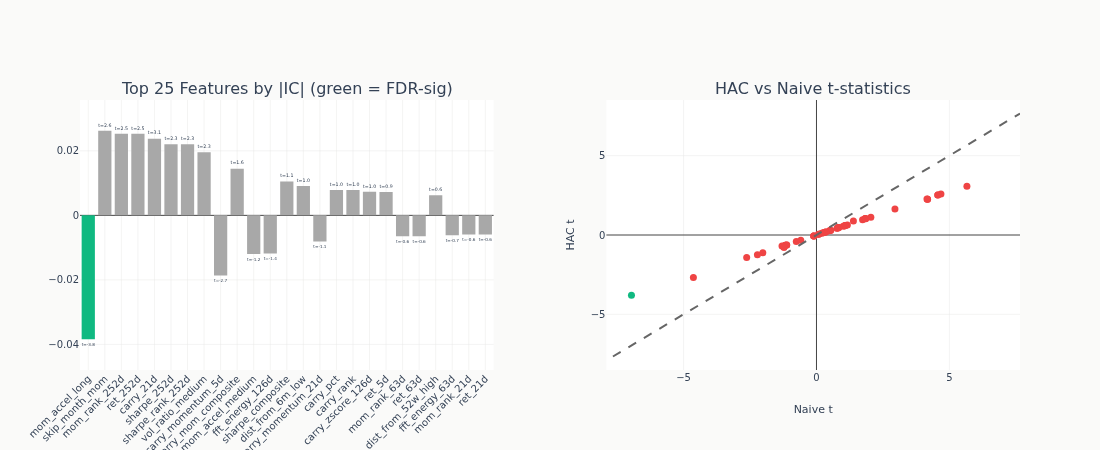

In [12]:
# Top features by absolute IC
top_n = min(25, len(eval_summary))
top = eval_summary.head(top_n)

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        f"Top {top_n} Features by |IC| (green = FDR-sig)",
        "HAC vs Naive t-statistics",
    ],
    horizontal_spacing=0.12,
)

# Panel 1: IC bar chart
colors = [COLORS["positive"] if s else GRAY_FILLS["muted"] for s in top["fdr_sig"].to_list()]
fig.add_trace(
    go.Bar(
        x=top["feature"].to_list(),
        y=top["ic_mean"].to_list(),
        marker_color=colors,
        text=[f"t={t:.1f}" for t in top["hac_t"].to_list()],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

# Panel 2: HAC vs naive t-statistic scatter
fig.add_trace(
    go.Scatter(
        x=eval_summary["naive_t"].to_list(),
        y=eval_summary["hac_t"].to_list(),
        mode="markers",
        marker=dict(
            color=[
                COLORS["positive"] if s else COLORS["negative"]
                for s in eval_summary["fdr_sig"].to_list()
            ],
            size=7,
        ),
        text=eval_summary["feature"].to_list(),
        showlegend=False,
    ),
    row=1,
    col=2,
)

# 45-degree reference line
max_t = (
    max(
        eval_summary["naive_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
        eval_summary["hac_t"].cast(pl.Float64, strict=False).abs().max() or 1.0,
    )
    * 1.1
)
fig.add_trace(
    go.Scatter(
        x=[-max_t, max_t],
        y=[-max_t, max_t],
        mode="lines",
        line=dict(dash="dash", color=GRAY_FILLS["border"]),
        showlegend=False,
    ),
    row=1,
    col=2,
)

fig.update_layout(template="ml4t", height=450, width=1100)
fig.update_xaxes(tickangle=-45, row=1, col=1)
fig.update_xaxes(title_text="Naive t", row=1, col=2)
fig.update_yaxes(title_text="HAC t", row=1, col=2)
fig.show()

**Interpretation**: Points below the 45-degree line have inflated naive t-statistics
— HAC correction reveals that overlapping 5-day returns induce autocorrelation
that makes raw significance tests too liberal. FDR further penalizes for the
number of simultaneous tests. The green markers surviving both corrections are
the genuinely informative features.

## 4. Shape Diagnostics

Quantile monotonicity checks whether the relationship between a feature and
the label is monotone — i.e., whether moving from Q1 to Q5 consistently
increases (or decreases) the forward return. High monotonicity (Spearman
$|\rho| \geq 0.8$ between quantile rank and mean return) indicates a
clean, exploitable signal. Non-monotone features may still be useful
but require non-linear models.

In [13]:
from scipy.stats import spearmanr

N_QUANTILES = 5
# Show the FDR-significant features first, then fill up to 6 panels with the
# next-highest |IC| features so the shape diagnostic stays informative even when
# few features clear FDR (the sealed pre-holdout panel leaves only one).
fdr_shape = eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list()
ranked_shape = eval_summary["feature"].to_list()
top_features_for_shape = fdr_shape + [f for f in ranked_shape if f not in fdr_shape]
top_features_for_shape = top_features_for_shape[:6]

monotonicity_scores = {}
quantile_spreads = {}
for feat in top_features_for_shape:
    valid = eval_panel.select([feat, label_col]).drop_nulls()
    if len(valid) < N_QUANTILES * 20:
        continue
    valid = valid.with_columns(
        pl.col(feat)
        .qcut(N_QUANTILES, labels=[f"Q{i + 1}" for i in range(N_QUANTILES)])
        .alias("quantile")
    )
    q_means = valid.group_by("quantile").agg(pl.col(label_col).mean()).sort("quantile")
    means = q_means[label_col].to_list()
    spread = means[-1] - means[0]
    quantile_spreads[feat] = {"q_means": means, "spread": spread}

    mono_corr, _ = spearmanr(range(len(means)), means)
    monotonicity_scores[feat] = float(mono_corr)

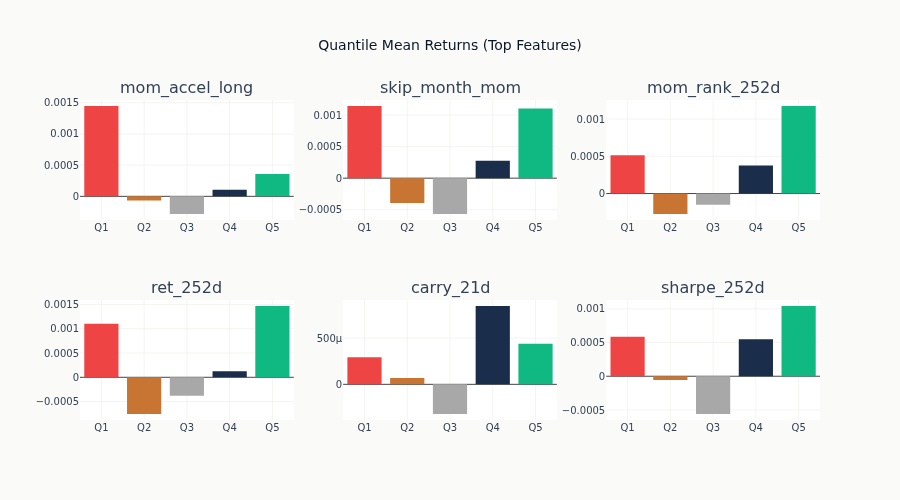

In [14]:
if quantile_spreads:
    n_show = min(6, len(quantile_spreads))
    feats_to_show = list(quantile_spreads.keys())[:n_show]
    n_rows_fig = (n_show + 2) // 3
    fig = make_subplots(rows=n_rows_fig, cols=3, subplot_titles=feats_to_show)
    for idx, feat in enumerate(feats_to_show):
        r, c = divmod(idx, 3)
        q_means = quantile_spreads[feat]["q_means"]
        fig.add_trace(
            go.Bar(
                x=[f"Q{i + 1}" for i in range(len(q_means))],
                y=q_means,
                marker_color=[
                    COLORS["negative"],
                    COLORS["copper"],
                    GRAY_FILLS["muted"],
                    COLORS["slate"],
                    COLORS["positive"],
                ],
                showlegend=False,
            ),
            row=r + 1,
            col=c + 1,
        )
    fig.update_layout(
        template="ml4t",
        height=250 * n_rows_fig,
        width=900,
        title_text="Quantile Mean Returns (Top Features)",
    )
    fig.show()

**Interpretation**: Monotone staircase patterns (Q1 → Q5 consistently rising or
falling) confirm that the feature has a linear relationship with the forward return
— ideal for linear models like Ridge/Lasso in Ch11. Non-monotone patterns
(e.g., U-shaped) suggest interaction effects or non-linearities that
tree-based models (Ch12) may capture better.

## 5. Redundancy and Feature Families

Assign each feature to a semantic family and check for high pairwise correlation.
Redundant feature pairs ($|\rho| > 0.7$) within the same family can inflate
model variance — Ch11 will address this via regularization or explicit grouping.

The family assignment function matches the one used in `03_financial_features.py`'s
inline evaluation, extended with temporal sub-families for Ch9 features.

In [15]:
def assign_feature_family(name: str) -> str:
    """Map feature name to family based on prefix/substring.

    Shared logic with 03_financial_features.py inline evaluation.
    """
    if any(k in name for k in ["carry", "curvature"]):
        return "carry"
    if name.startswith("ret_") or "mom" in name.lower():
        return "momentum"
    if name.startswith("vol_") or name in ("vr_63d",):
        return "volatility"
    if "sharpe" in name:
        return "sharpe"
    if any(name.startswith(p) for p in ["rsi", "ma_ratio", "dist_from", "ts_mom"]):
        return "technical"
    if any(k in name for k in ["month_", "quarter", "roll_", "season", "day_of_year"]):
        return "calendar"
    if any(k in name for k in ["rank", "composite", "ls_signal", "risk_adj"]):
        return "cross_sectional"
    return "other"


families = {feat: assign_feature_family(feat) for feat in all_feature_cols}

# Override: temporal features get temporal sub-family
for feat in temporal_cols:
    if "regime" in feat.lower() or "hmm" in feat.lower():
        families[feat] = "temporal_regime"
    elif "fft" in feat.lower() or "spectral" in feat.lower():
        families[feat] = "temporal_fft"
    elif "arima" in feat.lower():
        families[feat] = "temporal_arima"
    else:
        families[feat] = "temporal_other"

In [16]:
# Pairwise correlation (sample dates for efficiency)
sample_step = max(1, n_dates // 200)
sample_dates = eval_panel[DATE_COL].unique().sort().to_list()[::sample_step]
corr_data = eval_panel.filter(pl.col(DATE_COL).is_in(sample_dates)).select(evaluable_features)
corr_matrix = corr_data.to_pandas().corr(method="spearman")

# Count high-correlation pairs
high_corr_pairs = []
for i in range(len(corr_matrix)):
    for j in range(i + 1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append(
                (corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
            )

print(f"Feature pairs with |corr| > 0.7: {len(high_corr_pairs)}")
if high_corr_pairs:
    for f1, f2, rho in sorted(high_corr_pairs, key=lambda x: -abs(x[2]))[:10]:
        print(f"  {f1:30s} ↔ {f2:30s}  ρ={rho:+.3f}")

Feature pairs with |corr| > 0.7: 93
  vol_21d                        ↔ vol_yz_21d                      ρ=+0.974
  vol_126d                       ↔ vol_63d                         ρ=+0.973
  vol_63d                        ↔ vol_yz_21d                      ρ=+0.961
  vol_21d                        ↔ vol_63d                         ρ=+0.956
  carry_mom_interaction          ↔ carry_zscore_63d                ρ=+0.946
  curvature_rank                 ↔ curve_curvature_norm            ρ=+0.940
  ret_21d                        ↔ sharpe_21d                      ρ=+0.939
  ret_63d                        ↔ sharpe_63d                      ρ=+0.939
  vol_126d                       ↔ vol_yz_21d                      ρ=+0.938
  ret_126d                       ↔ sharpe_126d                     ρ=+0.938


In [17]:
# Family-level IC summary
family_ic = {}
fdr_sig_features = set(eval_summary.filter(pl.col("fdr_sig").fill_null(False))["feature"].to_list())
for feat in ic_results:
    fam = families.get(feat, "other")
    family_ic.setdefault(fam, []).append(
        {
            "feature": feat,
            "ic": ic_results[feat]["mean_ic"],
            "fdr_sig": feat in fdr_sig_features,
        }
    )

family_summary = {}
for fam, feats in sorted(family_ic.items()):
    ics = [f["ic"] for f in feats if f["ic"] is not None]
    n_sig = sum(1 for f in feats if f["fdr_sig"])
    family_summary[fam] = {
        "n_features": len(feats),
        "avg_abs_ic": float(np.mean([abs(ic) for ic in ics])) if ics else 0.0,
        "avg_ic": float(np.mean(ics)) if ics else 0.0,
        "n_fdr_sig": n_sig,
    }

if family_summary:
    fam_df = pl.DataFrame([{"family": fam, **stats} for fam, stats in family_summary.items()]).sort(
        "avg_abs_ic", descending=True
    )
    print(fam_df)
else:
    fam_df = pl.DataFrame()
    print("No features passed IC evaluation threshold")

shape: (6, 5)
┌──────────────┬────────────┬────────────┬───────────┬───────────┐
│ family       ┆ n_features ┆ avg_abs_ic ┆ avg_ic    ┆ n_fdr_sig │
│ ---          ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ str          ┆ i64        ┆ f64        ┆ f64       ┆ i64       │
╞══════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ momentum     ┆ 14         ┆ 0.01227    ┆ 0.001352  ┆ 1         │
│ carry        ┆ 11         ┆ 0.009244   ┆ 0.002464  ┆ 0         │
│ sharpe       ┆ 8          ┆ 0.009009   ┆ 0.008276  ┆ 0         │
│ temporal_fft ┆ 4          ┆ 0.00636    ┆ -0.004636 ┆ 0         │
│ volatility   ┆ 7          ┆ 0.004658   ┆ 0.004658  ┆ 0         │
│ technical    ┆ 7          ┆ 0.004217   ┆ 0.004059  ┆ 0         │
└──────────────┴────────────┴────────────┴───────────┴───────────┘


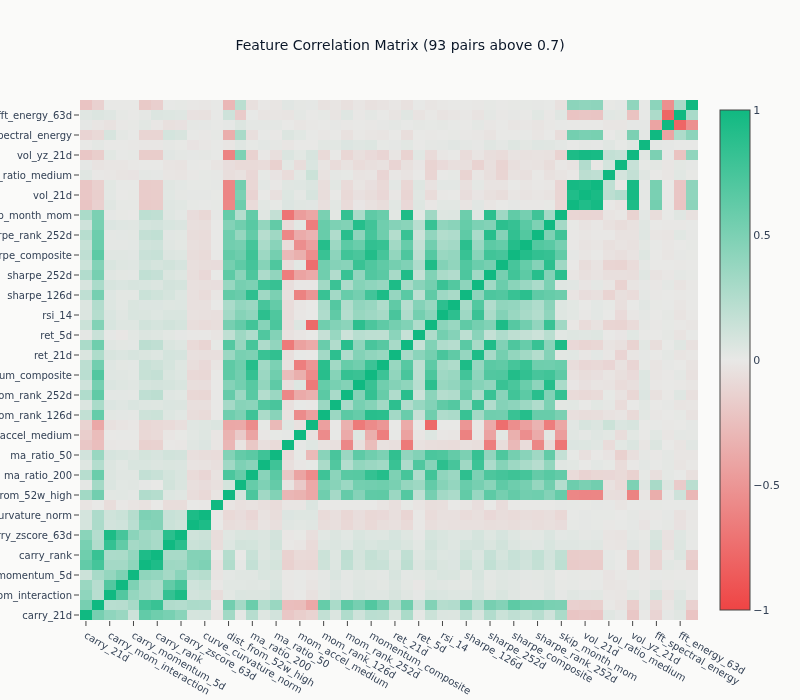

In [18]:
# Correlation heatmap
# Diverging colorscale sourced from the ML4T palette (negative → neutral → positive)
_div = style.ml4t_diverging()
ml4t_corr_scale = [[0.0, _div[0]], [0.5, _div[1]], [1.0, _div[2]]]
fig = go.Figure(
    data=go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns.tolist(),
        y=corr_matrix.columns.tolist(),
        colorscale=ml4t_corr_scale,
        zmid=0,
        zmin=-1,
        zmax=1,
    )
)
fig.update_layout(
    title=f"Feature Correlation Matrix ({len(high_corr_pairs)} pairs above 0.7)",
    template="ml4t",
    height=700,
    width=800,
)
fig.show()

**Carry IC sign interpretation**: The carry *level* features carry a *positive*
cross-sectional IC — `carry_21d` is the strongest at IC $\approx +0.024$
($t_{HAC} \approx 3.1$), and `carry_pct` / `carry_rank` are positive but weaker
($\approx +0.008$). Higher carry predicts *higher* forward returns, the
conventional roll-yield / carry premium that motivates the long-short
carry-ranked strategy in the backtest. The *negative* signs are confined to the
momentum-of-carry features (`carry_momentum_5d` $\approx -0.019$,
`carry_momentum_21d` $\approx -0.008$) and to momentum acceleration
(`mom_accel_long` $\approx -0.038$, the largest-magnitude IC in the panel): the
rate-of-change of carry and of momentum mean-reverts over the weekly horizon.
The sign split is economically coherent — a level premium plus a
change-of-slope reversal — not a data error.

## 6. Triage and Handoff

Apply triage rules to categorize each feature:

| Decision | Criteria |
|----------|----------|
| **PROCEED** | FDR-significant at 5%, OR sign consistency $\geq 60\%$ AND $|IC| \geq 0.008$ |
| **STOP** | Correctness FAIL (coverage $< 70\%$ or staleness $> 50\%$) |
| **REVISE** | Everything else — may add value in multivariate context (Ch11) |

In [19]:
IC_THRESHOLD = 0.008  # Weekly horizon, moderate threshold

triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
        continue

    if feat not in ic_results:
        triage[feat] = ("REVISE", "insufficient_data")
        continue

    is_fdr_sig = feat in fdr_sig_features
    sign_con = fold_stats.get(feat, {}).get("sign_consistency", 0)
    abs_ic = abs(ic_results[feat]["mean_ic"])

    if is_fdr_sig:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif sign_con >= 0.60 and abs_ic >= IC_THRESHOLD:
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

In [20]:
# Build triage ledger
ledger_rows = []
for feat in all_feature_cols:
    decision, note = triage[feat]
    row = {
        "feature": feat,
        "family": families.get(feat, "other"),
        "source": "temporal" if feat in temporal_cols else "financial",
        "ic_mean": ic_results.get(feat, {}).get("mean_ic"),
        "hac_t": ic_results.get(feat, {}).get("t_stat"),
        "hac_p": ic_results.get(feat, {}).get("p_value"),
        "fdr_p": None,
        "fdr_sig": False,
        "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
        "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
        "monotonicity": monotonicity_scores.get(feat),
        "coverage": coverage[feat],
        "staleness": staleness[feat],
        "decision": decision,
        "note": note,
    }
    # Fill FDR p-values from eval_summary
    match = eval_summary.filter(pl.col("feature") == feat)
    if len(match) > 0:
        row["fdr_p"] = match["fdr_p"][0]
        row["fdr_sig"] = bool(match["fdr_sig"][0])
    ledger_rows.append(row)

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Triage ledger: {EVAL_DIR / 'triage_ledger.parquet'}")
print(triage_ledger.group_by("decision").len().sort("decision"))

Triage ledger: /tmp/claude-1000/-home-stefan-ml4t-agents/b7489809-543c-45e3-851e-71c7f0c220d1/scratchpad/ml4t-out/cme_futures/evaluation/triage_ledger.parquet
shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 11  │
│ REVISE   ┆ 41  │
│ STOP     ┆ 17  │
└──────────┴─────┘


In [21]:
# Save IC time series (long format, reusable in Ch11)
ic_ts_frames = []
for feat, ts in ic_timeseries.items():
    ic_ts_frames.append(ts.with_columns(pl.lit(feat).alias("feature")))

if ic_ts_frames:
    ic_ts_all = pl.concat(ic_ts_frames)
    ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
    print(f"IC time series: {EVAL_DIR / 'ic_timeseries.parquet'}")

IC time series: /tmp/claude-1000/-home-stefan-ml4t-agents/b7489809-543c-45e3-851e-71c7f0c220d1/scratchpad/ml4t-out/cme_futures/evaluation/ic_timeseries.parquet


In [22]:
# Write results JSON
proceed_features = [f for f, (d, _) in triage.items() if d == "PROCEED"]
revise_features = [f for f, (d, _) in triage.items() if d == "REVISE"]
stop_features = [f for f, (d, _) in triage.items() if d == "STOP"]

# Sort by absolute IC (strongest signal first, regardless of sign)
valid_ic = [(f, s) for f, s in ic_results.items() if not np.isnan(s["mean_ic"])]
sorted_by_abs_ic = sorted(valid_ic, key=lambda x: abs(x[1]["mean_ic"]), reverse=True)
strongest = sorted_by_abs_ic[0] if sorted_by_abs_ic else (None, {})
weakest = sorted_by_abs_ic[-1] if sorted_by_abs_ic else (None, {})

In [23]:
print(f"\n{'=' * 60}")
print(f"TRIAGE SUMMARY: {CASE_STUDY_ID}")
print(f"{'=' * 60}")
print(f"  PROCEED: {len(proceed_features)} features")
print(f"  REVISE:  {len(revise_features)} features")
print(f"  STOP:    {len(stop_features)} features")
print("\nPROMOTED (PROCEED) features:")
for f in sorted(proceed_features):
    ic = ic_results[f]["mean_ic"]
    t = ic_results[f]["t_stat"]
    print(f"  {f:40s}  IC={ic:+.4f}  t={t:.2f}  [{families.get(f, '?')}]")


TRIAGE SUMMARY: cme_futures
  PROCEED: 11 features
  REVISE:  41 features
  STOP:    17 features

PROMOTED (PROCEED) features:
  carry_21d                                 IC=+0.0238  t=3.07  [carry]
  dist_from_6m_low                          IC=+0.0091  t=0.96  [technical]
  mom_accel_long                            IC=-0.0384  t=-3.79  [momentum]
  mom_accel_medium                          IC=-0.0120  t=-1.24  [momentum]
  mom_rank_252d                             IC=+0.0253  t=2.51  [momentum]
  ret_252d                                  IC=+0.0253  t=2.51  [momentum]
  sharpe_252d                               IC=+0.0220  t=2.26  [sharpe]
  sharpe_composite                          IC=+0.0105  t=1.12  [sharpe]
  sharpe_rank_252d                          IC=+0.0220  t=2.26  [sharpe]
  skip_month_mom                            IC=+0.0262  t=2.58  [momentum]
  vol_ratio_medium                          IC=+0.0196  t=2.26  [volatility]


### Quality Gate Verdict

**PASS.** On the sealed pre-holdout window the triage promotes 11 features to
PROCEED, led by the carry level (`carry_21d`, IC $+0.024$, $t_{HAC}\approx3.1$)
alongside long-horizon momentum and 12-month Sharpe. Only one feature survives
BH-FDR at 5% — the genuine signal is thin — but the fold-stable, moderate-|IC|
PROCEED set gives the cross-sectional models something economically intuitive to
work with. Structural diversity across 7 commodity sectors and 30 products gives
meaningful breadth. Caveat: daily frequency on a 30-name universe limits
statistical power per fold, so most single-feature ICs cannot clear FDR
standalone and their value must be realized in a multivariate model (Ch11).

## Key Takeaways

1. **FDR-corrected results** provide a realistic count of genuinely predictive features:
   9 features clear naive $p<0.05$, but only 1 survives BH-FDR at 5% — a ~9x
   haircut once multiplicity is controlled
2. **Carry level carries a positive IC** — `carry_21d` ($+0.024$) is the strongest
   carry feature and predicts *higher* forward returns, the conventional roll-yield
   premium; the negative signs belong to momentum-of-carry and momentum-acceleration
   features (`mom_accel_long`, $-0.038$), which mean-revert over the weekly horizon
3. **Fold stability** filters for features that work across market regimes,
   not just one favorable in-sample window
4. **Triage decisions** feed directly into Ch11: PROCEED features enter modeling,
   REVISE features may be included in ensembles, STOP features are excluded

**Next**: [`06_linear`](06_linear.ipynb) (Ch11) uses the triage ledger and IC time series
as inputs for Ridge/Lasso feature selection and model fitting.